# **Spam hunter**

---

## **Story**

You've just been recruited by the Digital Communications Intelligence Unit (DCIU), a shadow division tasked with protecting humanity from cyber threats. The world is drowning in spam from fake lottery wins to phishing scams. Your mission is clear: build an intelligent system using Python to detect and flag spam messages before they reach unsuspecting inboxes. This is your first real field assignment as a junior data agent.

## **Business Questions & Tasks**

1. What words appear most often in spam vs ham?
2. How accurate is your classifier?
3. Which messages are falsely labeled?
4. Does message length affect likelihood of spam?
5. What are the most predictive keywords or features?

---

In [68]:
from IPython.display import HTML, display
import numpy as np
import pandas as pd
import string
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.stats import mannwhitneyu

import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, f1_score, make_scorer, precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold


nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/anh-
[nltk_data]     dung/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Data loading and scanning

In [3]:
# read the csv file with encoding
df = pd.read_csv("spam_dataset.csv", encoding="latin-1")

# set column names
df.columns = ["label", "message", "res_1", "res_2", "res_3"] 

In [4]:
# scanning for basic information
df.info()

# display some rows for an overview
df.sample(8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   res_1    50 non-null     object
 3   res_2    12 non-null     object
 4   res_3    6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


,label,message,res_1,res_2,res_3
562,ham,Geeeee ... I love you so much I can barely sta...,NaN,NaN,NaN
4443,ham,COME BACK TO TAMPA FFFFUUUUUUU,NaN,NaN,NaN
117,ham,Goodo! Yes we must speak friday - egg-potato r...,NaN,NaN,NaN
1374,spam,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA...",NaN,NaN,NaN
2080,ham,Where is it. Is there any opening for mca.,NaN,NaN,NaN
2909,ham,How do you guys go to see movies on your side.,NaN,NaN,NaN
2883,ham,Cbe is really good nowadays:)lot of shop and s...,NaN,NaN,NaN
5245,ham,Thank you princess! I want to see your nice ju...,NaN,NaN,NaN


**Observation:** Most texts are in one column (one string), while others are splitted into two or more columns.

## 2. Data cleaning

In [5]:
#  Check for duplicated rows
print(df.duplicated().sum())

# Check for empty rows: either NaN or no character
print(df[(df.isna() | (df == "")).all(axis=1)])

403
Empty DataFrame
Columns: [label, message, res_1, res_2, res_3]
Index: []


**Comment:** 
- There are 403 duplicated rows -> needed to be drop.
- No empty rows.

In [6]:
# Remove duplicates
df = df.drop_duplicates(ignore_index=True)

In [7]:
# merge 4 message columns and strip leading/trailing whitespaces after merging
cols = ["message", "res_1", "res_2", "res_3"]

df["text"] = (
    df[cols]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.strip()
)

# remove redundant columns after merging
df = df.drop(columns=cols)

In [8]:
# remove punctuation
df["text"] = df["text"].str.replace(
    f"[{string.punctuation}]",
    "",
    regex=True
)


In the following, we create a new column `text_cleaned` which is obtained from `text` by lowering and removing stop words. This column is for a basis analysis in the next step. The column `text` will be ejected to the text classification pipeline.
(Lowering and stop words will be implemented in tokenization and vectorization in the pipeline)

In [9]:
# lowering the text
df["text_cleaned"] = df["text"].str.lower()

In [10]:
# Remove standard stop words in english
stop_words = set(stopwords.words("english"))

df["text_cleaned"] = df["text_cleaned"].apply(
    lambda x: " ".join( 
        word for word in x.split()
        if word not in stop_words
    )
)


## **3. A simple analysis**

Before building the pipeline for text classification, we plot the distributions of two labels. 

In [11]:
# distribution of ham and spam messages by counts
display(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64

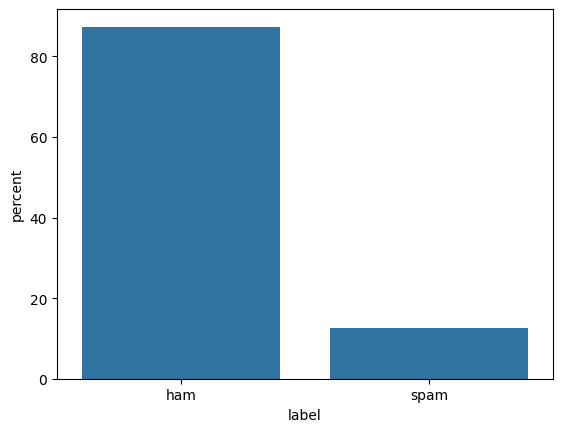

In [92]:
# Visualization the distribution of ham and spam messages by percentage
sns.countplot(data=df, x="label", stat="percent")
plt.savefig("distribution.png",bbox_inches='tight', pad_inches=0.05)

**Observation:** This dataset is imbalanced: the text labeled `spam` is less than 20% of the total entries.

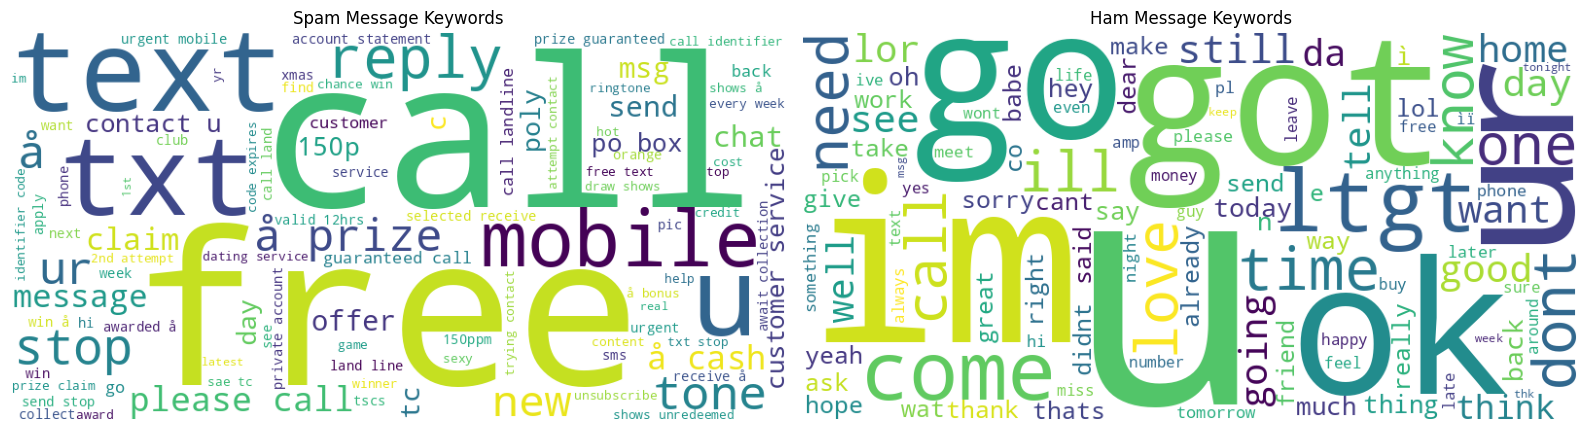

In [91]:
# Filter the data
spam_words = ' '.join(list(df[df['label'] == 'spam']['text_cleaned']))
ham_words = ' '.join(list(df[df['label'] == 'ham']['text_cleaned']))

# Configure the WordCloud object
cloud_params = {
    'width': 800, 
    'height': 400, 
    'background_color': 'white', 
    'max_words': 100
}

spam_cloud = WordCloud(**cloud_params).generate(spam_words)
ham_cloud = WordCloud(**cloud_params).generate(ham_words)

# Visualize
fig_cloud, ax_cloud = plt.subplots(1,2,figsize=(16, 10))

# Spam Cloud
ax_cloud[0].imshow(spam_cloud)
ax_cloud[0].set_title('Spam Message Keywords')
ax_cloud[0].axis('off')

# Ham Cloud
ax_cloud[1].imshow(ham_cloud)
ax_cloud[1].set_title('Ham Message Keywords')
ax_cloud[1].axis('off')
plt.tight_layout()
plt.show()
fig_cloud.savefig("wordcloud.png",bbox_inches='tight', pad_inches=0.05)


**Observation:** 
- Some tokens frequently appearing in the spam messages include `call`, `free`, `text`, `txt` or `reply`.
- Some tokens frequently appearing in the ham messages include `Im`, `go`, `got`, `ok`, or`come`.

In [14]:
# check avg. length of each label
df["length"] = df["text"].apply(len)
print(df.groupby('label')['length'].agg(['mean','median']))

             mean  median
label                    
ham     67.153233    50.0
spam   132.482389   143.0


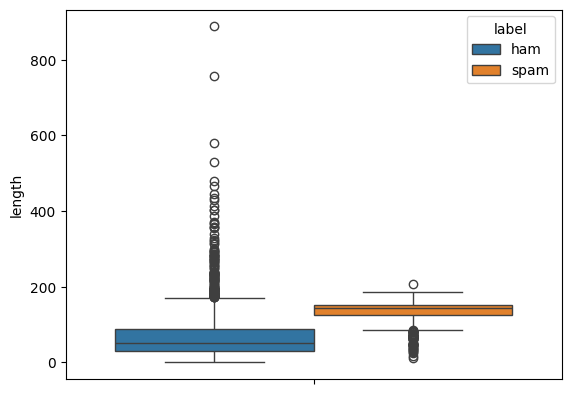

In [90]:
# visualize the length distributions for comparison
sns.boxplot(data=df, y="length", hue="label")
plt.savefig("length.png",bbox_inches='tight', pad_inches=0.05)

**Observation:** spam messages tend to be longer than ham messages.

To be more statistically assured, let's perform a Mann-Whitney U test (as distributions are non-normal)

In [16]:
# Mann-Whitney U test:
# H0: The length distributions of lengths for Spam and Ham are the same.
# H1: The length of Spam messages is significantly different than Ham messages.
# alpha = 0.5
spam_lengths = df[df['label'] == 'spam']['length']
ham_lengths = df[df['label'] == 'ham']['length']
stat, p_value = mannwhitneyu(spam_lengths, ham_lengths)

print(f"Statistics={stat:.3f}, p-value={p_value:.3e}")

if p_value < 0.05:
    print("Reject H0 -> Significant difference between Spam's length and Ham's length!")
    print(f"Median(Spam) = {spam_lengths.median()} - Median(Ham) = {ham_lengths.median()}")
    if spam_lengths.median() > ham_lengths.median():
        print("Spams are significantly longer than Hams")
    else:
        print("Hams are significantly longer than Spams")
else:
    print("Fail to reject H0 -> No significant difference between Spam's length and Ham's length!")


Statistics=2588157.500, p-value=2.525e-214
Reject H0 -> Significant difference between Spam's length and Ham's length!
Median(Spam) = 143.0 - Median(Ham) = 50.0
Spams are significantly longer than Hams


## **4. Train-test split**

In [17]:
X = df["text"]
y = df["label"]

# Train/test split. 
# Due to the imbalance nature of the dataset, we use the stratified split. 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)


## **5. Pipeline Definition** 

In [42]:
# Tokenization and Vectorization
vectorizer = TfidfVectorizer(
    lowercase=True,      # Lowercase trasnform
    tokenizer=None,      # Using default word-level tokenization
    stop_words='english',# Stop-words removal
    ngram_range=(1, 2)   # Capturing work and phrases
)

# NB pipeline
nb_model = Pipeline([
    ('vectorizer', vectorizer), # Preprocessing & Vectorization
    ('nb', MultinomialNB())   # Classifier
])

# Logit pipeline
lr_model = Pipeline([
    ('vectorizer', vectorizer), # Preprocessing & Vectorization
    ('scaler', MaxAbsScaler()), # because of regularization
    ('logit', LogisticRegression(solver='liblinear', class_weight='balanced'))   # Classifier
])


## **6. Model evaluation**

In [43]:
# define muliple scores with spam as the target
scorers = {
    'f1': make_scorer(f1_score, pos_label='spam'),
    'precision': make_scorer(precision_score, pos_label='spam'),
    'recall': make_scorer(recall_score, pos_label='spam')
}

# define stratified cv for imbalanced dataset
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)



In [34]:
# Optimize NB model

# parameter space
nb_param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

# fit
nb_model.fit(X_train, y_train)

# Run GridSearchCV with the Stratified strategy
nb_grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_param_grid,
    cv=skf,           # Explicitly passing StratifiedKFold
    scoring=scorers,
    refit='f1',  # use f1 to pick the final 'winning' model
    n_jobs=-1, 
    verbose=0
)

# training
nb_grid_search.fit(X_train, y_train)

#print the best params
print(nb_grid_search.best_params_)

{'nb__alpha': 0.1, 'vectorizer__ngram_range': (1, 2)}


In [44]:
# Optimize the logit pipeline 

# parameter space
logit_param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'logit__C': [0.1, 1, 10, 100],
    'logit__penalty': ['l1', 'l2'],
    'logit__max_iter': [3000, 5000, 8000]
}


# Run GridSearchCV with the Stratified strategy
logit_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=logit_param_grid,
    cv=skf,           # Explicitly passing StratifiedKFold
    scoring=scorers,  
    refit='f1',  # use f1 to pick the final 'winning' model
    n_jobs=-1, 
    verbose=0
)

# training
logit_grid_search.fit(X_train, y_train)

#print the best params
print(logit_grid_search.best_params_)


{'logit__C': 100, 'logit__max_iter': 3000, 'logit__penalty': 'l2', 'vectorizer__ngram_range': (1, 1)}


/home/anh-dung/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [46]:
# make predictions on unseen data with naive bayes
nb_predictions = nb_grid_search.predict(X_test)
# check the performance
print("Naive Bayes:")
print(classification_report(y_test, nb_predictions, digits=3))

# make predictions on unseen data with logistic regression
logit_predictions = logit_grid_search.predict(X_test)
# check the performance
print("Logistic regression:")
print(classification_report(y_test, logit_predictions, digits=3))

Naive Bayes:
              precision    recall  f1-score   support

         ham      0.978     0.998     0.988       903
        spam      0.982     0.847     0.910       131

    accuracy                          0.979      1034
   macro avg      0.980     0.923     0.949      1034
weighted avg      0.979     0.979     0.978      1034

Logistic regression:
              precision    recall  f1-score   support

         ham      0.984     0.996     0.990       903
        spam      0.967     0.885     0.924       131

    accuracy                          0.982      1034
   macro avg      0.975     0.941     0.957      1034
weighted avg      0.981     0.982     0.981      1034



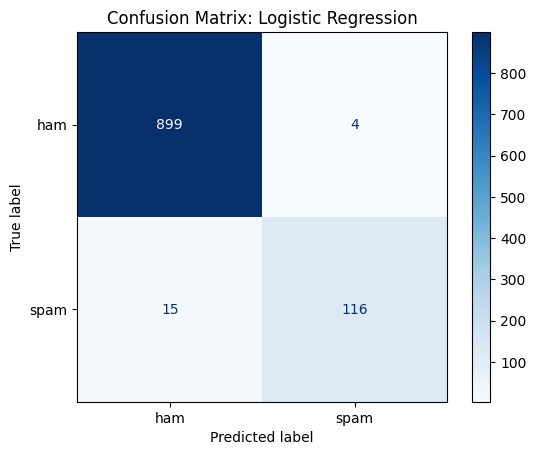

In [89]:
# Visualization: Confusion Matrix for LR
ConfusionMatrixDisplay.from_estimator(logit_grid_search.best_estimator_, 
                                      X_test, 
                                      y_test, 
                                      cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.savefig("confusion_matrix.png",bbox_inches='tight', pad_inches=0.05)
plt.show()

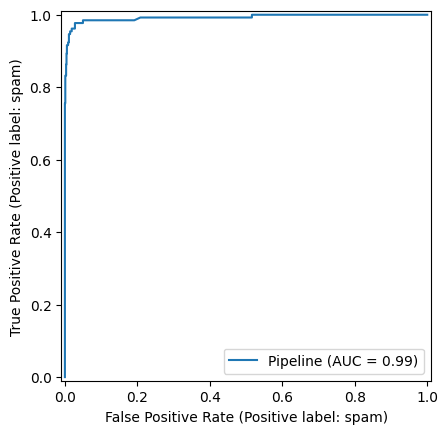

In [93]:
# Plot the ROC curve for the best model from your Grid Search
RocCurveDisplay.from_estimator(logit_grid_search.best_estimator_, X_test, y_test)
plt.savefig("roc_curve.png",bbox_inches='tight', pad_inches=0.05)

**Observations:**

1. Naive Bayes and Logistic Regression have the relatively similar performance on ham messages. The weighted avg precision, recall, and f1 scores are also quite similar for both classifiers. In fact, in overall, Logistic Regression performs slightly better than Naive Bayes on these measures.
2. On spam messages:
   - Precision: Naive Bayes acts slightly better than Logistic Regression. For Naive Bayes, 2.8% of spam-labeled messages are actually hams. For Logistic Regression, 3.3% of spam-labeled messages are actually hams.
   - Recall: On this measure, Logistic Regression acts better than Naive Bayes. LR successfully catches about 88.5% of all the spam messages, while NB is less effective (84.7%).
   - F1-score: Logistic Regression's score of 0.924 proves it handles the trade-off between "missing spam" and "false alarms" more effectively than Naive Bayes (0.910).

**Conclusion:** In overall, Logistic Regression is better for production than Naive Bayes for spam detection.

In [55]:
# Check top ten predictive words

# Get the feature names and coefficients from the best Logistic Model
best_lr_model = logit_grid_search.best_estimator_
feature_names = best_lr_model.named_steps['vectorizer'].get_feature_names_out()
coefficients = best_lr_model.named_steps['logit'].coef_[0]
# gathering in a dataframe and sorting
importance = pd.Series(coefficients, index=feature_names).sort_values(ascending=False)
# top ten predictive words for Spam
print("Top ten predictive words for Spam:")
display(importance.head(10))
# top ten predictive words for Ham
print("\nTop ten predictive words for Ham:")
display(importance.tail(10))

Top ten predictive words for Spam:


07090201529    7.121738
service        6.003812
won            5.520914
claim          5.454505
new            5.389072
22             5.236929
urgent         5.216769
txt            5.118449
146tf150p      5.042036
message        4.934802
dtype: float64


Top ten predictive words for Ham:


said       -2.065830
happy      -2.066938
princess   -2.130999
did        -2.165530
home       -2.270272
ok         -2.308950
road       -2.404533
ltgt       -2.632543
ill        -2.705136
liked      -5.658818
dtype: float64

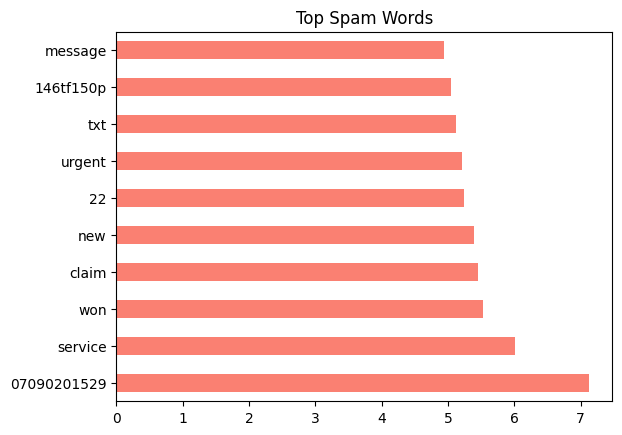

In [94]:
# visualization Spam's important words
importance.head(10).plot(kind='barh', color='salmon')
plt.title("Top Spam Words")
plt.savefig("top_words_spam.png",bbox_inches='tight', pad_inches=0.05)

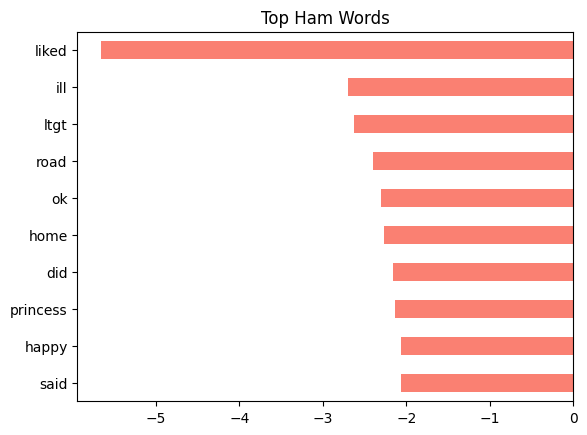

In [95]:
# visualization Ham's important words
importance.tail(10).plot(kind='barh', color='salmon')
plt.title("Top Ham Words")
plt.savefig("top_words_ham.png",bbox_inches='tight', pad_inches=0.05)